# From co-presence to coordination

## Main lesson

Temporal order, a shared file, the same task, and coordination are
different constructs. This notebook shows how the candidate set narrows
as the evidence becomes stronger. It does not estimate true handoff
prevalence, and the AI-assisted screen is not human ground truth.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"
CACHE = ROOT / "outputs" / "cache"

required = [
    TABLES / "direct_continuity_funnel.csv",
    TABLES / "direct_continuity_composition.csv",
    TABLES / "direct_continuity_threshold_sensitivity.csv",
    TABLES / "direct_continuity_screen_diagnostic.csv",
    CACHE / "direct_continuity_candidates.parquet",
    FIGURES / "direct_continuation_funnel.png",
]
missing = [str(path) for path in required if not path.exists()]
assert not missing, f"Run scripts/analysis/run_direct_continuity_analysis.py; missing: {missing}"

## RQ1 -- Measurement funnel

,stage,n,share_of_eligible
0,Eligible closed-unmerged PRs,37110,100.0%
1,Any later PR in 30 days,30343,81.8%
2,Exact-file successor in 30 days,19405,52.3%
3,Possible continuation candidate,6105,16.5%
4,Strong continuation candidate,4413,11.9%
5,Strong candidate changes agent,92,0.2%
6,"Strong candidate: same contributor, new agent",11,0.0%


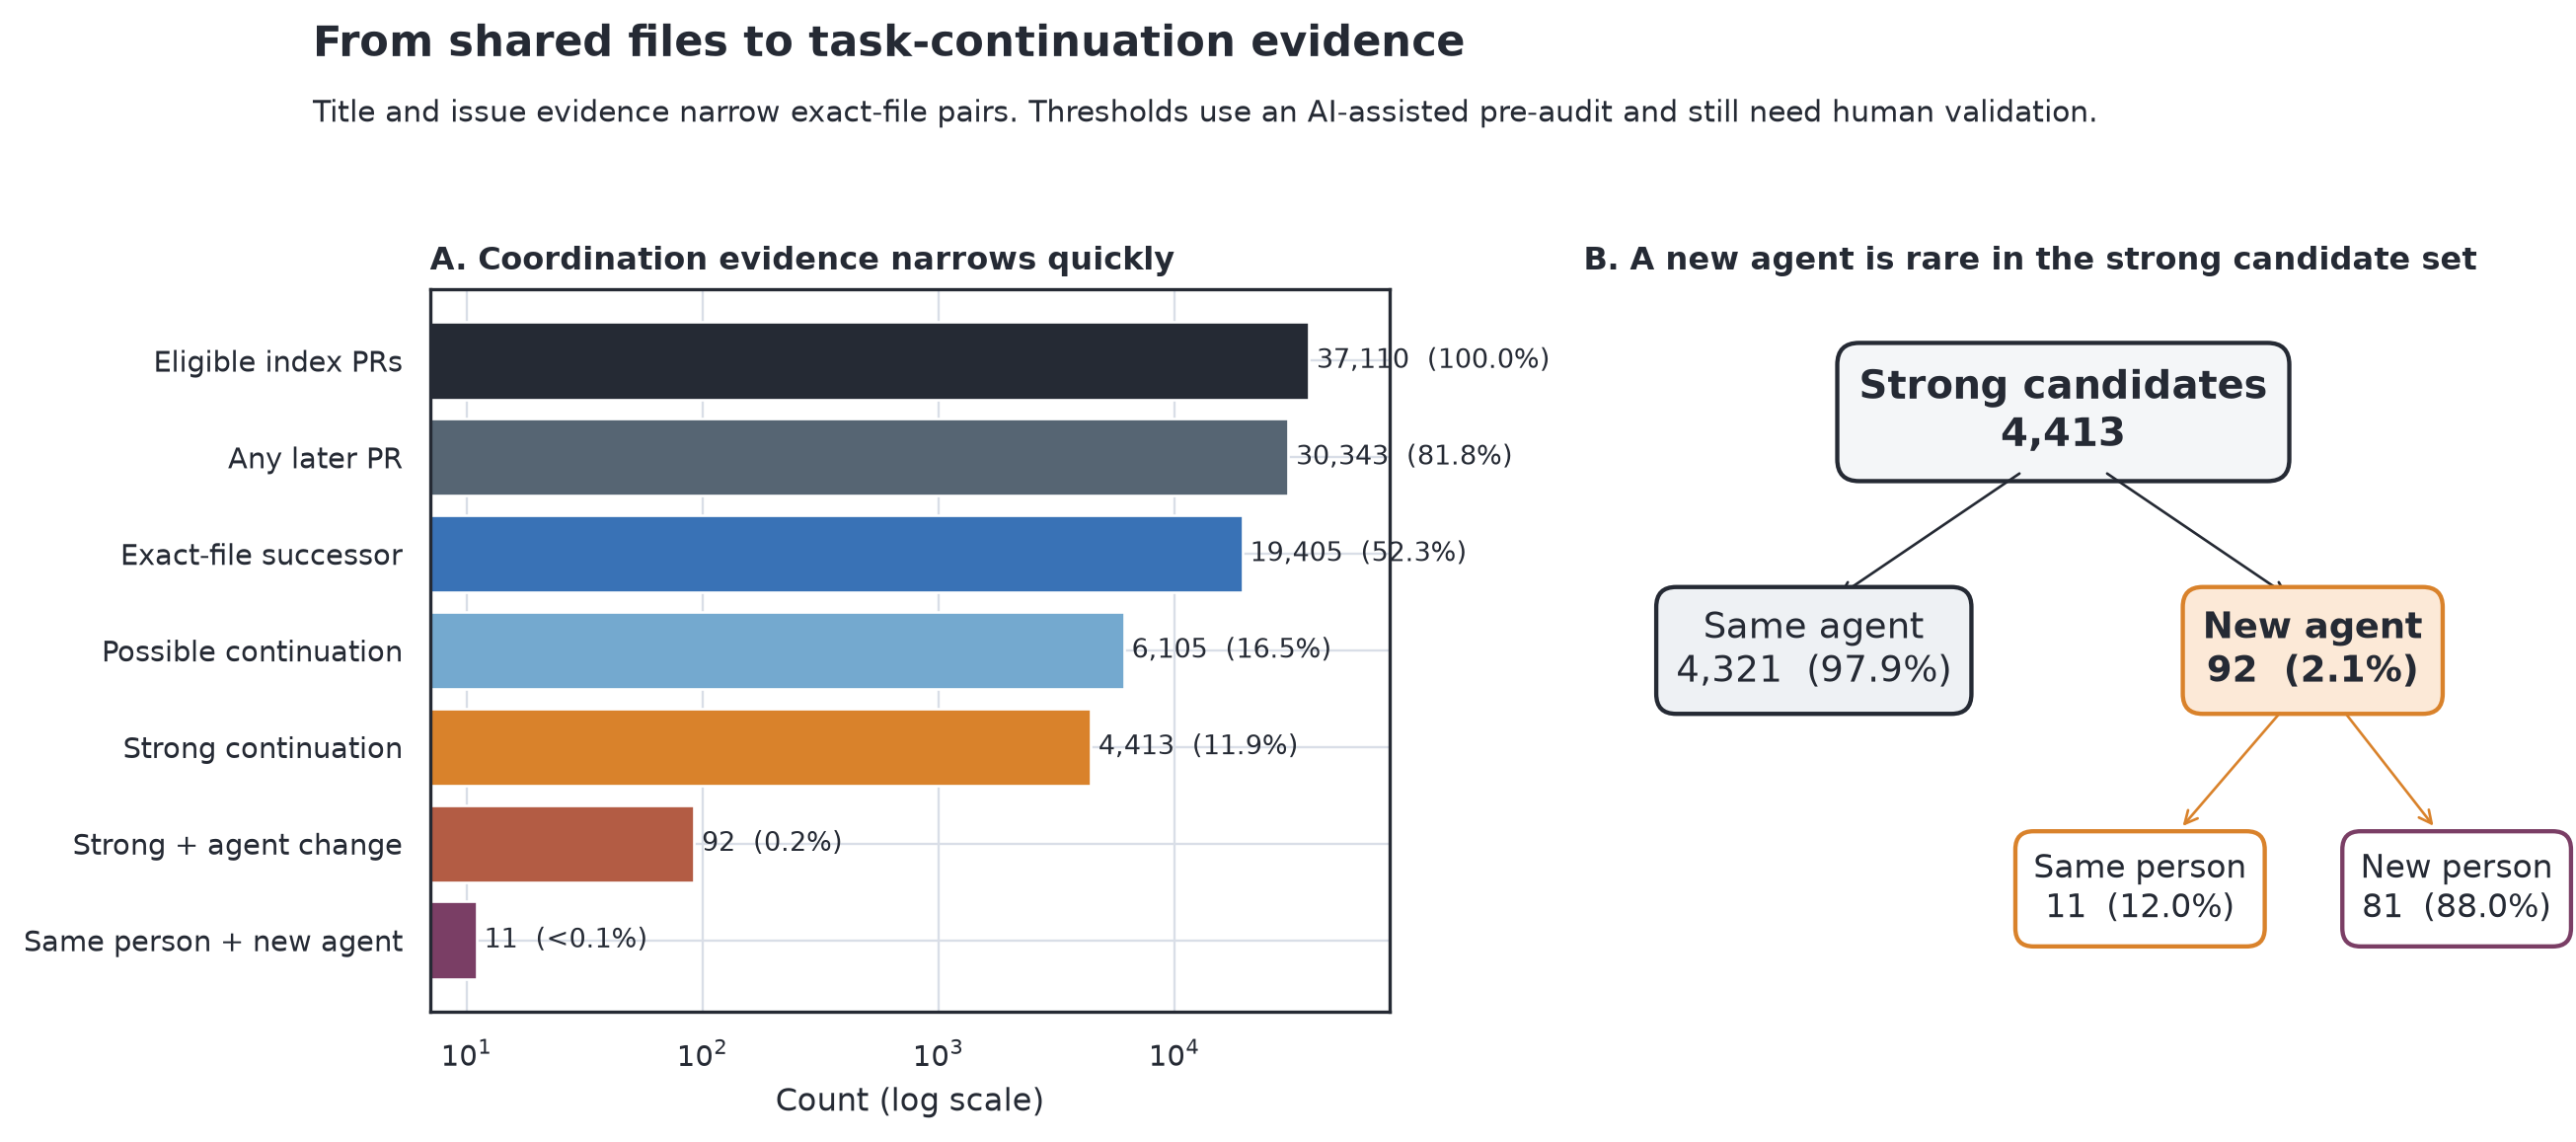

In [2]:
funnel = pd.read_csv(TABLES / "direct_continuity_funnel.csv")
shown = funnel.copy()
shown["share_of_eligible"] = shown["share_of_eligible"].map(lambda value: f"{value:.1%}")
display(shown)
display(Image(filename=str(FIGURES / "direct_continuation_funnel.png")))

An exact-file successor is a candidate generator, not a same-task label.
The strong rule uses shared issue evidence or title similarity of at
least 0.20. It was chosen after a pre-audit and needs held-out human
validation.

## RQ2 -- Proxy diagnostic

In [3]:
diagnostic = pd.read_csv(TABLES / "direct_continuity_screen_diagnostic.csv")
shown = diagnostic[[
    "title_threshold", "selected_n", "true_positive_n",
    "false_positive_n", "false_negative_n", "screen_precision",
    "screen_recall", "title_score_auc", "validation_status"
]].copy()
shown["screen_precision"] = shown["screen_precision"].map(lambda value: f"{value:.1%}")
shown["screen_recall"] = shown["screen_recall"].map(lambda value: f"{value:.1%}")
shown["title_score_auc"] = shown["title_score_auc"].map(lambda value: f"{value:.3f}")
display(shown)

,title_threshold,selected_n,true_positive_n,false_positive_n,false_negative_n,screen_precision,screen_recall,title_score_auc,validation_status
0,0.050,12,8,4,1,66.7%,88.9%,0.974,AI-assisted pre-audit; not human ground truth
1,0.075,10,8,2,1,80.0%,88.9%,0.974,AI-assisted pre-audit; not human ground truth
2,0.100,9,8,1,1,88.9%,88.9%,0.974,AI-assisted pre-audit; not human ground truth
3,0.150,8,7,1,2,87.5%,77.8%,0.974,AI-assisted pre-audit; not human ground truth
4,0.200,6,6,0,3,100.0%,66.7%,0.974,AI-assisted pre-audit; not human ground truth
5,0.250,3,3,0,6,100.0%,33.3%,0.974,AI-assisted pre-audit; not human ground truth
6,0.300,3,3,0,6,100.0%,33.3%,0.974,AI-assisted pre-audit; not human ground truth
7,0.400,1,1,0,8,100.0%,11.1%,0.974,AI-assisted pre-audit; not human ground truth


The diagnostic uses 9 consensus-positive and 73 consensus-negative
endpoints from two AI-assisted screens. Since the screens also used
titles, the AUC is not an independent classifier result. Its purpose is
to design the human study.

## RQ3 -- Does the multi-agent story survive stricter rules?

In [4]:
sensitivity = pd.read_csv(TABLES / "direct_continuity_threshold_sensitivity.csv")
shown = sensitivity.copy()
shown["candidate_share_of_exact_file"] = shown["candidate_share_of_exact_file"].map(lambda value: f"{value:.1%}")
display(shown)

,title_threshold,candidate_n,candidate_share_of_exact_file,changed_agent_n,same_contributor_changed_agent_n,repositories
0,0.050,7711,39.7%,255,26,1727
1,0.075,6807,35.1%,203,20,1616
2,0.100,6105,31.5%,167,17,1537
3,0.150,5116,26.4%,124,12,1398
4,0.200,4413,22.7%,92,11,1295
5,0.250,3901,20.1%,69,10,1201
6,0.300,3493,18.0%,58,8,1117
7,0.400,2859,14.7%,36,6,977


The exact candidate count changes with the threshold, but one result is
stable: cross-agent continuation candidates are a small subset, and most
also change contributor. The old merge flag is only later-successor
integration by a common deadline; it is not failed-task recovery.

## Next gate

Run `scripts/audit/build_human_audit_packets.py`, complete both blinded coder
files, report agreement and adjudication, then validate the rule on a
held-out set. Do not make an agent-effect claim before this step.